# ECG Arrhythmia Classification Using CNN-LSTM

## Project Update 1: Initial EDA and Preprocessing

This notebook loads the **MIT-BIH Arrhythmia Database v1.0.0** directly from
PhysioNet, audits its recordings and expert annotations, and demonstrates an
initial beat-level preprocessing pipeline. Model training is intentionally out
of scope for this update.

**Dataset:** https://physionet.org/content/mitdb/1.0.0/  
**Database DOI:** https://doi.org/10.13026/C2F305  
**Reproducibility:** raw data is streamed with `wfdb`; no local data upload is required.


## 1. Environment setup

Run this notebook with an internet-enabled Google Colab runtime. The first cell
installs WFDB, the official Python interface used to read PhysioNet waveform and
annotation files.


In [ ]:
%pip -q install "wfdb>=4.1,<5"


In [1]:
from collections import Counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import butter, sosfiltfilt
import wfdb

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

DB_NAME = "mitdb"
SAMPLE_RECORD = "100"
PRE_SAMPLES = 180
POST_SAMPLES = 180
WINDOW_SAMPLES = PRE_SAMPLES + POST_SAMPLES

# Week 4 uses a representative subset for initial preprocessing. Change this to
# True in Week 5 after validating the pipeline and runtime requirements.
PROCESS_ALL_RECORDS = False
PREVIEW_RECORDS = ["100", "118", "200", "208", "217"]


## 2. Dataset loading and structural validation

Each MIT-BIH record has a header (`.hea`), a two-channel waveform (`.dat`), and
reference beat annotations (`.atr`). We first obtain the official record list and
validate one complete record before running the database-wide audit.


In [2]:
records = wfdb.get_record_list(DB_NAME)
print(f"Records available: {len(records)}")
print(records)
assert len(records) == 48, "Expected 48 MIT-BIH records."


Records available: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [3]:
sample = wfdb.rdrecord(SAMPLE_RECORD, pn_dir=DB_NAME)
sample_ann = wfdb.rdann(SAMPLE_RECORD, "atr", pn_dir=DB_NAME)

sample_summary = pd.Series({
    "record": SAMPLE_RECORD,
    "sampling_frequency_hz": sample.fs,
    "channels": sample.n_sig,
    "channel_names": ", ".join(sample.sig_name),
    "samples_per_channel": sample.sig_len,
    "duration_minutes": sample.sig_len / sample.fs / 60,
    "annotation_count": len(sample_ann.sample),
}, name="value")
display(sample_summary.to_frame())

assert sample.p_signal.shape == (sample.sig_len, sample.n_sig)
assert len(sample_ann.sample) == len(sample_ann.symbol)
assert sample.fs == 360


                           value
record                       100
sampling_frequency_hz        360
channels                       2
channel_names           MLII, V5
samples_per_channel       650000
duration_minutes       30.092593
annotation_count            2274

## 3. Database-wide metadata and annotation audit

The audit loads only headers and compact annotation files, so it is much faster
than downloading every waveform. It establishes record duration, sampling rate,
lead availability, annotation counts, and the original label distribution.


In [4]:
metadata_rows = []
raw_label_counts = Counter()

for record_name in records:
    header = wfdb.rdheader(record_name, pn_dir=DB_NAME)
    ann = wfdb.rdann(record_name, "atr", pn_dir=DB_NAME)
    metadata_rows.append({
        "record": record_name,
        "sampling_frequency_hz": header.fs,
        "channels": header.n_sig,
        "channel_names": ", ".join(header.sig_name),
        "samples_per_channel": header.sig_len,
        "duration_minutes": header.sig_len / header.fs / 60,
        "annotation_count": len(ann.sample),
    })
    raw_label_counts.update(ann.symbol)

metadata_df = pd.DataFrame(metadata_rows)
display(metadata_df.head())
display(metadata_df.describe(include="all").T)

assert metadata_df["record"].nunique() == 48
assert set(metadata_df["sampling_frequency_hz"]) == {360.0}
assert metadata_df["channels"].min() == 2


  record  sampling_frequency_hz  ...  duration_minutes annotation_count
0    100                    360  ...         30.092593             2274
1    101                    360  ...         30.092593             1874
2    102                    360  ...         30.092593             2192
3    103                    360  ...         30.092593             2091
4    104                    360  ...         30.092593             2311

[5 rows x 7 columns]

                      count unique       top  ...        50%        75%        max
record                   48     48       100  ...        NaN        NaN        NaN
sampling_frequency_hz  48.0    NaN       NaN  ...      360.0      360.0      360.0
channels               48.0    NaN       NaN  ...        2.0        2.0        2.0
channel_names            48      6  MLII, V1  ...        NaN        NaN        NaN
samples_per_channel    48.0    NaN       NaN  ...   650000.0   650000.0   650000.0
duration_minutes       48.0    NaN       NaN  ...  30.092593  30.092593  30.092593
annotation_count       48.0    NaN       NaN  ...     2299.0    2650.25     3400.0

[7 rows x 11 columns]

  channel_configuration  records
0              MLII, V1       40
1              MLII, V5        2
2                V5, V2        2
3              MLII, V2        2
4              V5, MLII        1
5              MLII, V4        1

   annotation  count
0           N  75052
1           L   8075
2           R   7259
3           V   7130
4           /   7028
5           A   2546
6           +   1291
7           f    982
8           F    803
9           ~    616
10          !    472
11          "    437
12          j    229
13          x    193
14          a    150
15          |    132
16          E    106
17          J     83
18          Q     33
19          e     16
20          [      6
21          ]      6
22          S      2

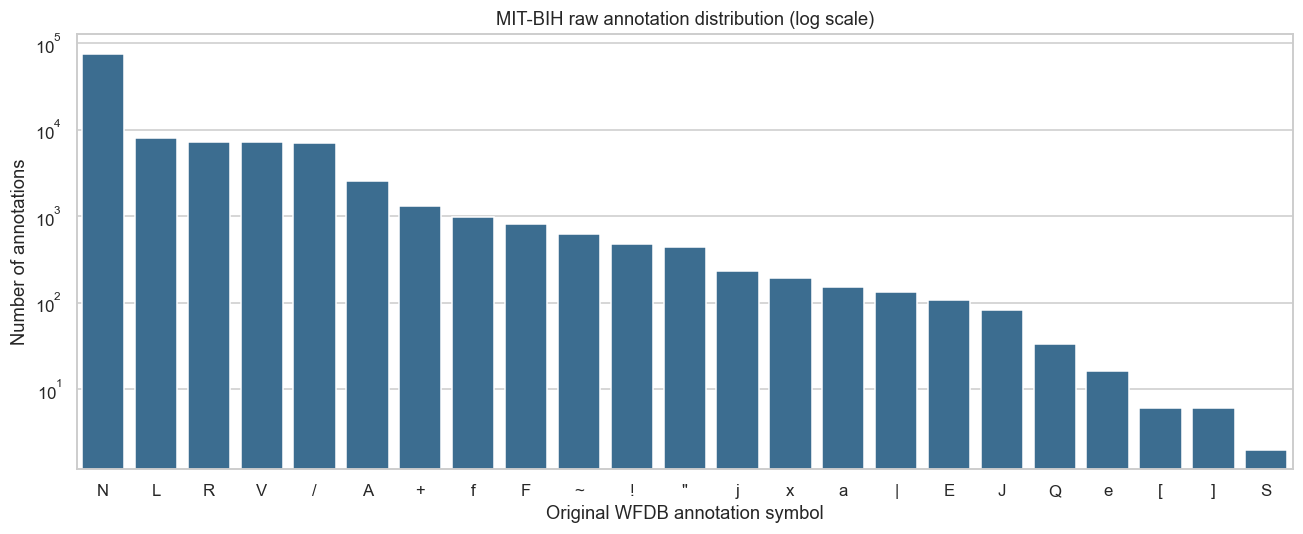

In [5]:
channel_inventory = (
    metadata_df["channel_names"]
    .value_counts()
    .rename_axis("channel_configuration")
    .reset_index(name="records")
)
display(channel_inventory)

raw_counts_df = (
    pd.DataFrame(raw_label_counts.items(), columns=["annotation", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
display(raw_counts_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=raw_counts_df, x="annotation", y="count", color="#2E6F9E")
plt.yscale("log")
plt.title("MIT-BIH raw annotation distribution (log scale)")
plt.xlabel("Original WFDB annotation symbol")
plt.ylabel("Number of annotations")
plt.tight_layout()
plt.show()


### Preliminary AAMI-style grouping

The raw symbols are retained above for transparency. For later model development,
beat annotations are provisionally grouped into the five AAMI-style superclasses
used by the reviewed MIT-BIH literature. Non-beat rhythm and signal-quality markers
are not treated as classification targets.

- **N:** normal and normal-like beats
- **S:** supraventricular ectopic beats
- **V:** ventricular ectopic beats
- **F:** fusion beats
- **Q:** paced, fusion-of-paced, or unclassifiable beats


Ignored non-target annotation symbols: {'+': 1291, '~': 616, '|': 132, 'x': 193, '[': 6, '!': 472, ']': 6, '"': 437}


  class  count
0     N  90631
1     S   2781
2     V   7236
3     F    803
4     Q   8043

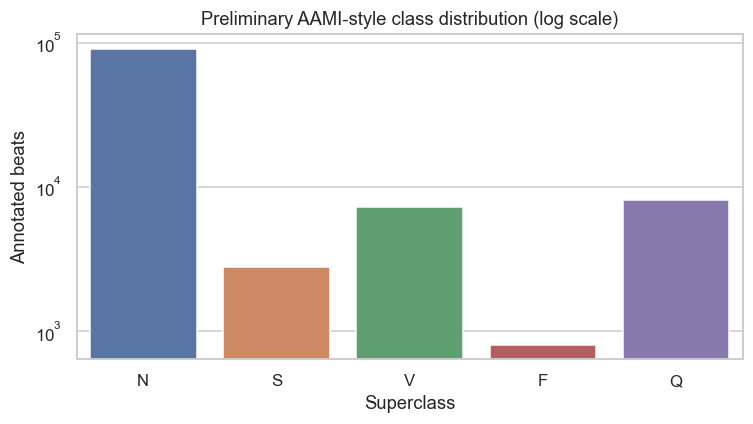

In [6]:
AAMI_SYMBOLS = {
    "N": {"N", "L", "R", "e", "j"},
    "S": {"A", "a", "J", "S"},
    "V": {"V", "E"},
    "F": {"F"},
    "Q": {"/", "f", "Q", "U"},
}
SYMBOL_TO_AAMI = {
    symbol: group
    for group, symbols in AAMI_SYMBOLS.items()
    for symbol in symbols
}

grouped_counts = Counter()
ignored_counts = Counter()
for symbol, count in raw_label_counts.items():
    if symbol in SYMBOL_TO_AAMI:
        grouped_counts[SYMBOL_TO_AAMI[symbol]] += count
    else:
        ignored_counts[symbol] += count

grouped_df = pd.DataFrame(
    {"class": list("NSVFQ"), "count": [grouped_counts[c] for c in "NSVFQ"]}
)
display(grouped_df)
print("Ignored non-target annotation symbols:", dict(ignored_counts))

plt.figure(figsize=(7, 4))
sns.barplot(data=grouped_df, x="class", y="count", hue="class", legend=False,
            palette="deep")
plt.yscale("log")
plt.title("Preliminary AAMI-style class distribution (log scale)")
plt.xlabel("Superclass")
plt.ylabel("Annotated beats")
plt.tight_layout()
plt.show()


## 4. ECG and annotation visualization

The plot below shows ten seconds from record 100. Reference beat annotations are
overlaid at their sample locations. The first lead is used only for this visualization;
the lead inventory above must inform the final channel policy.


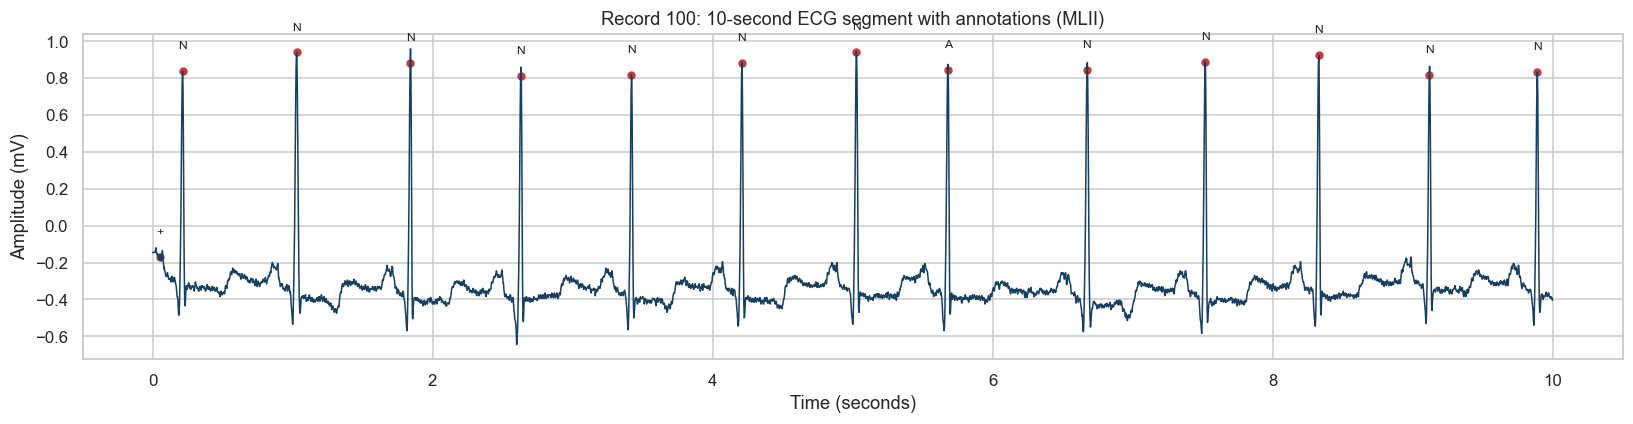

In [7]:
start_sample = 0
end_sample = int(10 * sample.fs)
time_s = np.arange(start_sample, end_sample) / sample.fs
lead_index = sample.sig_name.index("MLII") if "MLII" in sample.sig_name else 0
lead_name = sample.sig_name[lead_index]
segment = sample.p_signal[start_sample:end_sample, lead_index]

mask = (sample_ann.sample >= start_sample) & (sample_ann.sample < end_sample)
ann_samples = sample_ann.sample[mask]
ann_symbols = np.asarray(sample_ann.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(time_s, segment, color="#173F5F", linewidth=1)
for ann_sample, symbol in zip(ann_samples, ann_symbols):
    local_index = int(ann_sample - start_sample)
    plt.scatter(ann_sample / sample.fs, segment[local_index], color="#C43D3D", s=20)
    plt.text(ann_sample / sample.fs, segment[local_index] + 0.12, symbol,
             fontsize=8, ha="center")
plt.title(f"Record {SAMPLE_RECORD}: 10-second ECG segment with annotations ({lead_name})")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()


## 5. Initial preprocessing pipeline

This preliminary pipeline applies a 0.5-40 Hz Butterworth bandpass filter, extracts
one-second windows centered on expert annotations (180 samples before and after),
maps eligible annotations to five superclasses, and standardizes each beat. These
choices are deliberately easy to audit and will be revisited after baseline models.

For the Week 4 submission, the default processes five records as a representative
initial run. Set `PROCESS_ALL_RECORDS = True` only after validating runtime and the
final lead policy during Week 5.


In [8]:
def choose_lead(record):
    # Prefer MLII when present; otherwise use channel zero and report the fallback.
    return record.sig_name.index("MLII") if "MLII" in record.sig_name else 0


def bandpass_ecg(signal, fs, low_hz=0.5, high_hz=40.0, order=4):
    sos = butter(order, [low_hz, high_hz], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)


def standardize_beat(beat, eps=1e-8):
    return (beat - beat.mean()) / (beat.std() + eps)


def extract_record_beats(record_name):
    record = wfdb.rdrecord(record_name, pn_dir=DB_NAME)
    ann = wfdb.rdann(record_name, "atr", pn_dir=DB_NAME)
    lead_index = choose_lead(record)
    raw_signal = record.p_signal[:, lead_index]
    filtered_signal = bandpass_ecg(raw_signal, record.fs)

    beats, labels, raw_examples = [], [], []
    skipped_boundary = 0
    skipped_non_target = 0

    for peak, symbol in zip(ann.sample, ann.symbol):
        target = SYMBOL_TO_AAMI.get(symbol)
        if target is None:
            skipped_non_target += 1
            continue

        left, right = int(peak - PRE_SAMPLES), int(peak + POST_SAMPLES)
        if left < 0 or right > len(filtered_signal):
            skipped_boundary += 1
            continue

        raw_beat = raw_signal[left:right]
        filtered_beat = filtered_signal[left:right]
        beats.append(standardize_beat(filtered_beat).astype(np.float32))
        labels.append(target)
        if len(raw_examples) < 3:
            raw_examples.append((raw_beat, filtered_beat, target, symbol))

    return {
        "beats": beats,
        "labels": labels,
        "examples": raw_examples,
        "lead": record.sig_name[lead_index],
        "skipped_boundary": skipped_boundary,
        "skipped_non_target": skipped_non_target,
    }


In [9]:
preprocessing_records = records if PROCESS_ALL_RECORDS else PREVIEW_RECORDS
all_beats, all_labels, all_record_ids = [], [], []
preprocessing_rows = []
first_examples = None

for record_name in preprocessing_records:
    result = extract_record_beats(record_name)
    all_beats.extend(result["beats"])
    all_labels.extend(result["labels"])
    all_record_ids.extend([record_name] * len(result["labels"]))
    if first_examples is None and result["examples"]:
        first_examples = result["examples"]
    preprocessing_rows.append({
        "record": record_name,
        "selected_lead": result["lead"],
        "extracted_beats": len(result["beats"]),
        "skipped_boundary": result["skipped_boundary"],
        "skipped_non_target": result["skipped_non_target"],
    })

X = np.stack(all_beats)
y = np.asarray(all_labels)
record_ids = np.asarray(all_record_ids)
preprocessing_df = pd.DataFrame(preprocessing_rows)

display(preprocessing_df)
print("Records processed:", len(preprocessing_records))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", dict(Counter(y)))
print("Contains NaN:", bool(np.isnan(X).any()))
print("Contains infinity:", bool(np.isinf(X).any()))

assert X.ndim == 2 and X.shape[1] == WINDOW_SAMPLES
assert len(X) == len(y) == len(record_ids)
assert np.isfinite(X).all()


Records processed: 5
X shape: (12309, 360)
y shape: (12309,)
Class counts: {'N': 7973, 'S': 161, 'V': 1997, 'F': 374, 'Q': 1804}
Contains NaN: False
Contains infinity: False


  record selected_lead  extracted_beats  skipped_boundary  skipped_non_target
0    100          MLII             2271                 2                   1
1    118          MLII             2277                 1                  23
2    200          MLII             2600                 1                 191
3    208          MLII             2953                 2                  85
4    217          MLII             2208                 0                  72

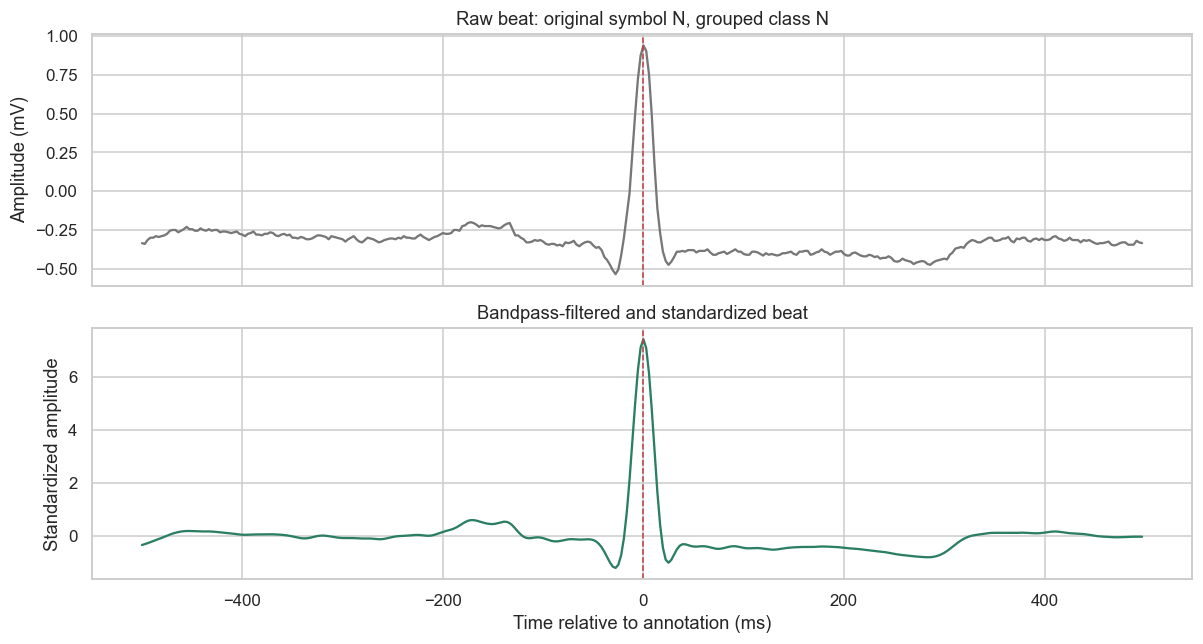

In [10]:
raw_beat, filtered_beat, target, original_symbol = first_examples[0]
time_ms = (np.arange(WINDOW_SAMPLES) - PRE_SAMPLES) / 360 * 1000

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(time_ms, raw_beat, color="#777777")
axes[0].set_title(f"Raw beat: original symbol {original_symbol}, grouped class {target}")
axes[0].set_ylabel("Amplitude (mV)")
axes[1].plot(time_ms, standardize_beat(filtered_beat), color="#2A7F62")
axes[1].set_title("Bandpass-filtered and standardized beat")
axes[1].set_xlabel("Time relative to annotation (ms)")
axes[1].set_ylabel("Standardized amplitude")
for axis in axes:
    axis.axvline(0, color="#C43D3D", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


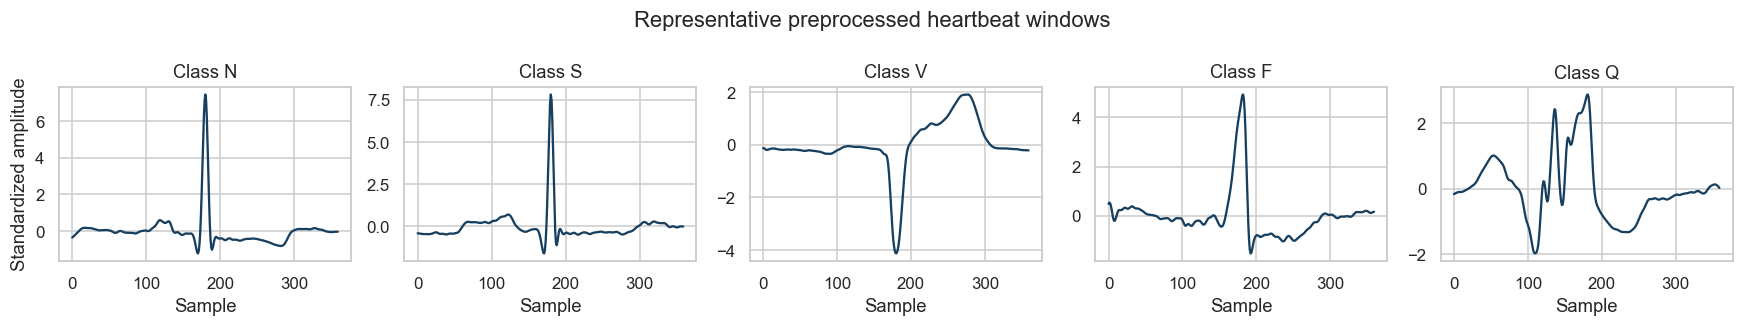

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharex=True)
for axis, class_name in zip(axes, list("NSVFQ")):
    indices = np.flatnonzero(y == class_name)
    if len(indices):
        axis.plot(X[indices[0]], color="#173F5F")
        axis.set_title(f"Class {class_name}")
    else:
        axis.text(0.5, 0.5, "Not present\nin preview", ha="center", va="center",
                  transform=axis.transAxes)
        axis.set_title(f"Class {class_name}")
    axis.set_xlabel("Sample")
axes[0].set_ylabel("Standardized amplitude")
fig.suptitle("Representative preprocessed heartbeat windows")
plt.tight_layout()
plt.show()


## 6. Leakage-aware split design for later modeling

The notebook does **not** train a model in Project Update 1. When modeling begins,
beats from the same record must not be randomly divided across training and test
sets. The commonly used inter-patient DS1/DS2 protocol below keeps evaluation
records separate and excludes four paced-beat records. Any oversampling or class
weighting must be applied only after the training records are selected.


In [12]:
DS1_TRAIN_RECORDS = [
    "101", "106", "108", "109", "112", "114", "115", "116", "118", "119", "122",
    "124", "201", "203", "205", "207", "208", "209", "215", "220", "223", "230",
]
DS2_TEST_RECORDS = [
    "100", "103", "105", "111", "113", "117", "121", "123", "200", "202", "210",
    "212", "213", "214", "219", "221", "222", "228", "231", "232", "233", "234",
]
EXCLUDED_PACED_RECORDS = ["102", "104", "107", "217"]

assert set(DS1_TRAIN_RECORDS).isdisjoint(DS2_TEST_RECORDS)
assert len(DS1_TRAIN_RECORDS) == len(DS2_TEST_RECORDS) == 22
print("Planned inter-patient split: 22 training records, 22 test records, 4 excluded paced records.")


Planned inter-patient split: 22 training records, 22 test records, 4 excluded paced records.


## 7. Initial findings and next steps

**Initial findings**

1. MIT-BIH provides 48 two-channel, half-hour recordings sampled at 360 Hz with
   expert beat annotations.
2. Annotation frequencies are strongly imbalanced; normal-like beats dominate,
   while fusion and supraventricular classes are comparatively rare.
3. Channel configurations vary, so the final lead-selection rule must be documented.
4. One-second annotation-centered windows produce consistent numerical inputs and
   allow visual verification before model development.
5. Random beat-level splitting would leak patient-specific morphology; record-wise
   evaluation is therefore required.

**Next update**

- Complete preprocessing for the selected record protocol.
- Compare alternative filtering, normalization, and window lengths.
- Apply class balancing only to training records.
- Implement baseline CNN, LSTM, and CNN-LSTM models.
- Report macro-F1, per-class sensitivity/recall, specificity, precision, and confusion matrices.

**Limitation:** annotation-centered segmentation assumes reference R-peak locations.
A deployable system would require a separately validated beat detector.


## References

1. Moody, G. B., & Mark, R. G. (2001). The impact of the MIT-BIH Arrhythmia Database.
   *IEEE Engineering in Medicine and Biology Magazine, 20*(3), 45-50.
2. Goldberger, A. L., et al. (2000). PhysioBank, PhysioToolkit, and PhysioNet.
   *Circulation, 101*(23), e215-e220.
3. Mousavi, S., Afghah, F., & Acharya, U. R. (2019). Inter- and intra-patient ECG
   heartbeat classification for arrhythmia detection: A sequence-to-sequence deep
   learning approach. *ICASSP 2019*, 1308-1312.
